In [39]:
import pandas as pd
import numpy as np
from scipy import stats 
import matplotlib.pyplot as plt


In [ ]:
# Direct download link to a CSV file stored on Google Drive
url = 'https://drive.google.com/uc?export=download&id=1eR3NZtwIC6ECN3vhtrynqmx8okG0twA7'
chess = pd.read_csv(url)

In [ ]:
# Calculate the absolute difference between white and black player ratings
chess['rating_diff'] = abs(chess['white_rating'] - chess['black_rating'])

In [ ]:
# Generate descriptive statistics for the rating difference column
# This includes count, mean, std, min, max, and quartiles
descripe = chess['rating_diff'].describe()
skew =chess['rating_diff'].skew()
iqr = chess['rating_diff'].quantile(0.75) - chess['rating_diff'].quantile(0.25)
print('discribeing the statiscs :' , descripe , '\nthe skew is ' ,skew , '\nthe iqr ' , iqr)


discribeing the statiscs : count    20058.000000
mean       173.091435
std        179.214854
min          0.000000
25%         45.000000
50%        115.000000
75%        241.000000
max       1605.000000
Name: rating_diff, dtype: float64 
the skew is  1.9486762216717806 
the iqr  196.0


In [ ]:
# Generate descriptive statistics for the 'turns' column (game length)
# This includes count, mean, standard deviation, min, max, and quartiles
descripe_rating = chess['turns'].describe()
skew_rating =chess['turns'].skew()
iqr_rating = chess['turns'].quantile(0.75) - chess['turns'].quantile(0.25)
print('discribeing the statiscs :' , descripe_rating , '\nthe skew is ' ,skew_rating , '\nthe iqr ' , iqr_rating)


discribeing the statiscs : count    20058.000000
mean        60.465999
std         33.570585
min          1.000000
25%         37.000000
50%         55.000000
75%         79.000000
max        349.000000
Name: turns, dtype: float64 
the skew is  0.897283771438351 
the iqr  42.0


In [37]:
# Perform Shapiro-Wilk test for normality on a sample of 'rating_diff'
# A random sample of 1000 rows is used for computational efficiency
stat_diff, p_diff = stats.shapiro(chess['rating_diff'].sample(1000, random_state=42))
stat_rated, p_rated = stats.shapiro(chess['turns'].sample(1000, random_state=42))
print(f"Shapiro-Wilk p = {p_diff:.6f}")
print(f"Shapiro-Wilk p = {p_rated:.6f}")


Shapiro-Wilk p = 0.000000
Shapiro-Wilk p = 0.000000


In [ ]:
# Apply log transformation (log(1 + x)) to reduce skewness and handle large values

chess['turns_log'] = np.log1p(chess['turns'])
chess['rating_diff_log'] = np.log1p(chess['rating_diff'])


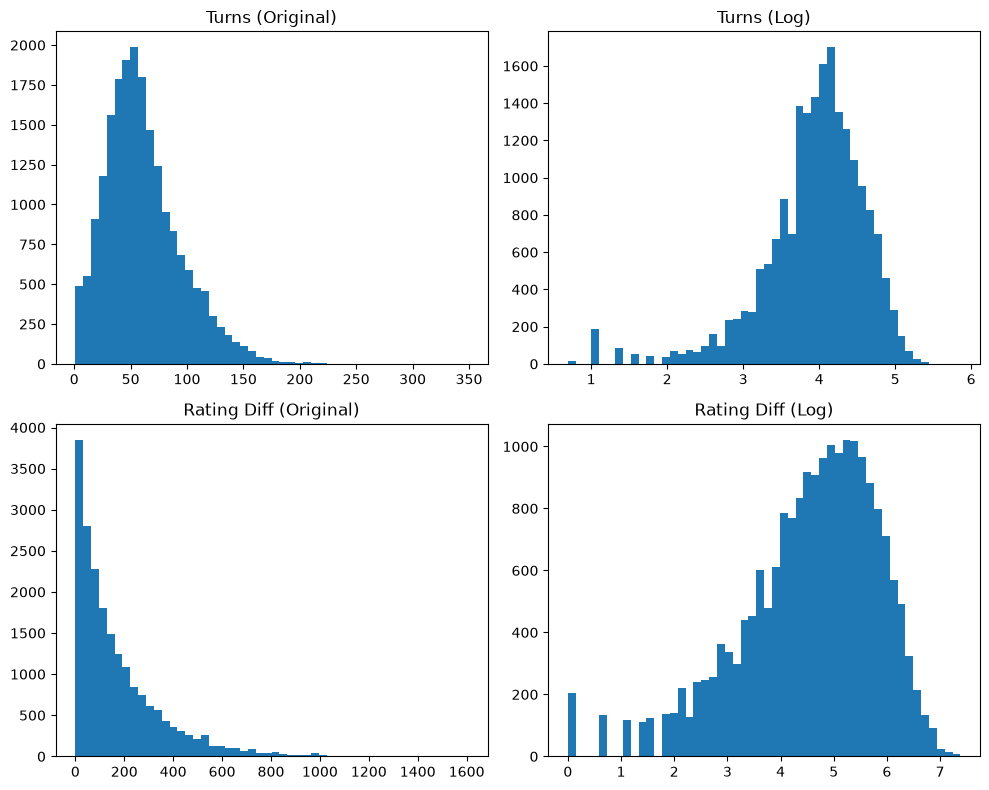

In [43]:
# Create a 2x2 grid of subplots to compare original vs log-transformed distributions
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# turns original
ax[0,0].hist(chess['turns'], bins=50)
ax[0,0].set_title("Turns (Original)")

# turns log
ax[0,1].hist(chess['turns_log'], bins=50)
ax[0,1].set_title("Turns (Log)")

# rating_diff original
ax[1,0].hist(chess['rating_diff'], bins=50)
ax[1,0].set_title("Rating Diff (Original)")

# rating_diff log
ax[1,1].hist(chess['rating_diff_log'], bins=50)
ax[1,1].set_title("Rating Diff (Log)")

plt.tight_layout()

# 💾 save image
plt.savefig("outputImages/distribution_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [45]:
# Compare skewness before and after log transformation
# Skewness shows how asymmetric the distribution is

print("Turns skew (original):", chess['turns'].skew())
print("Turns skew (log):", chess['turns_log'].skew())

print("Rating_diff skew (original):", chess['rating_diff'].skew())
print("Rating_diff skew (log):", chess['rating_diff_log'].skew())

Turns skew (original): 0.897283771438351
Turns skew (log): -1.3708338858711593
Rating_diff skew (original): 1.9486762216717806
Rating_diff skew (log): -0.9005824660211456
